In [34]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 1. SETUP PARAMETER DASAR (Uang Saku Rp2.000.000, Tinggal Bersama Ortu)
start_date = datetime(2026, 1, 1)
end_date = datetime(2026, 6, 30)
date_range = [start_date + timedelta(days=x) for x in range((end_date - start_date).days + 1)]

monthly_income = 2000000
data_rows = []

# Target Total Pengeluaran Bulanan (Mengunci grafik tren utama)
monthly_targets = {
    '2026-01': 1600000, '2026-02': 1550000, '2026-03': 1650000,
    '2026-04': 2300000, '2026-05': 1200000, '2026-06': 1150000
}

# ALOKASI RASIO PERSENTASE DINAMIS PER BULAN (Kunci Cerita Proyek Progresif!)
# Total masing-masing bulan wajib berjumlah 1.0 (100%)
monthly_ratios = {
    '2026-01': {'Food & Dining': 0.55, 'Shopping': 0.09, 'Groceries': 0.11, 'Transportation': 0.10, 'Bills & Utilities': 0.05, 'Education': 0.05, 'Entertainment': 0.05},
    '2026-02': {'Food & Dining': 0.57, 'Shopping': 0.08, 'Groceries': 0.10, 'Transportation': 0.11, 'Bills & Utilities': 0.04, 'Education': 0.05, 'Entertainment': 0.05},
    '2026-03': {'Food & Dining': 0.54, 'Shopping': 0.11, 'Groceries': 0.09, 'Transportation': 0.10, 'Bills & Utilities': 0.06, 'Education': 0.05, 'Entertainment': 0.05},
    # April: Fase Boros Radikal -> Shopping naik ke 18%, Entertainment naik ke 12%, Makanan pokok tertekan secara rasio
    '2026-04': {'Food & Dining': 0.44, 'Shopping': 0.18, 'Groceries': 0.08, 'Transportation': 0.09, 'Bills & Utilities': 0.04, 'Education': 0.05, 'Entertainment': 0.12},
    # Mei & Juni: Fase Tobat/Hemat -> Shopping & Hiburan ambles ke 3%, pengeluaran kembali ke kebutuhan pokok
    '2026-05': {'Food & Dining': 0.62, 'Shopping': 0.03, 'Groceries': 0.12, 'Transportation': 0.11, 'Bills & Utilities': 0.04, 'Education': 0.05, 'Entertainment': 0.03},
    '2026-06': {'Food & Dining': 0.64, 'Shopping': 0.03, 'Groceries': 0.10, 'Transportation': 0.12, 'Bills & Utilities': 0.04, 'Education': 0.04, 'Entertainment': 0.03}
}

# Template Deskripsi Transaksi
templates = {
    'Food & Dining': ['Makan siang di kantin kampus', 'Nasi Padang lauk ayam', 'Makan malam Warteg', 'Sarapan bubur ayam komplek', 'Nongkrong di Coffee Shop', 'Beli Kopi Susu Kekinian', 'Jajan Mixue bareng teman', 'Makan Shihlin / McD'],
    'Transportation': ['Isi bensin Pertalite motor', 'Top up e-money Commuter Line', 'Gojek ke stasiun'],
    'Groceries': ['Belanja bulanan kebutuhan harian di Alfamart', 'Beli stok sabun, sampo & detergen Indomaret'],
    'Shopping': ['Beli Baju', 'Checkout barang di Tokopedia', 'Beli barang lucu'],
    'Bills & Utilities': ['Isi pulsa paket data internet', 'Top up saldo e-wallet harian'],
    'Education': ['Fotokopi tugas kuliah', 'Iuran kas angkatan', 'Print laporan praktikum'],
    'Entertainment': ['Tiket nonton bioskop XXI', 'Top up voucher game', 'Langganan Spotify Premium'],
    'Others': ['Bayar parkir mall/kampus', 'Patungan kado teman wisuda']
}

# 2. PROSES GENERATION
# Masukkan Income di setiap tanggal 1
for date in date_range:
    month_str = date.strftime('%Y-%m')
    weekday_str = date.strftime('%A')

    if date.day == 1:
        data_rows.append({
            'Date': date.strftime('%Y-%m-%d'), 'Description': 'Uang Saku Bulanan dari Ortu',
            'Amount': monthly_income, 'TransactionCategory': 'Allowance / Salary',
            'PaymentMethod': 'Transfer Bank', 'TransactionType': 'Income',
            'Weekday': weekday_str, 'Month': month_str
        })

# Eksekusi pembagian dana dinamis harian
for month, target_total in monthly_targets.items():
    days_in_month = [d for d in date_range if d.strftime('%Y-%m') == month]
    num_days = len(days_in_month)
    ratios = monthly_ratios[month]

    # Hitung nominal dana total kategori untuk bulan ini berdasarkan kamus rasio dinamis
    cat_budgets = {cat: int(target_total * ratio) for cat, ratio in ratios.items()}

    # --- A. Distribusi Food & Dining (Menyebar merata 2 kali sehari) ---
    num_food_tx = num_days * 2
    food_amounts = np.array([cat_budgets['Food & Dining'] // num_food_tx] * num_food_tx)

    # --- B. Distribusi Transportation (Menyebar merata harian) ---
    trans_amounts = np.array([cat_budgets['Transportation'] // num_days] * num_days)

    # --- C. Distribusi Shopping & Groceries (Sistem Transaksi Besar Berkala / Undian Hari) ---
    num_shop_tx = 3 if month == '2026-04' else 1
    shop_days = np.random.choice(range(1, num_days+1), size=num_shop_tx, replace=False)
    shop_amt_per_tx = np.array([cat_budgets['Shopping'] // num_shop_tx] * num_shop_tx)

    num_groc_tx = 2
    groc_days = np.random.choice([d for d in range(1, num_days+1) if d not in shop_days], size=num_groc_tx, replace=False)
    groc_amt_per_tx = np.array([cat_budgets['Groceries'] // num_groc_tx] * num_groc_tx)

    # --- D. Distribusi Kategori Kecil Lainnya ---
    bills_days = np.random.choice(range(1, num_days+1), size=2, replace=False)
    edu_days = np.random.choice(range(1, num_days+1), size=2, replace=False)
    ent_days = np.random.choice(range(1, num_days+1), size=3 if month == '2026-04' else 1, replace=False)

    food_idx = 0
    for day_idx, date_obj in enumerate(days_in_month):
        hari_ke = date_obj.day

        # 1. Masukkan Makanan Harian (2x transaksi)
        for _ in range(2):
            data_rows.append({
                'Date': date_obj.strftime('%Y-%m-%d'), 'Description': np.random.choice(templates['Food & Dining']),
                'Amount': int(food_amounts[food_idx]), 'TransactionCategory': 'Food & Dining', 'PaymentMethod': 'QRIS',
                'TransactionType': 'Expenses', 'Weekday': date_obj.strftime('%A'), 'Month': month
            })
            food_idx += 1

        # 2. Masukkan Transportasi Harian
        data_rows.append({
            'Date': date_obj.strftime('%Y-%m-%d'), 'Description': np.random.choice(templates['Transportation']),
            'Amount': int(trans_amounts[day_idx]), 'TransactionCategory': 'Transportation', 'PaymentMethod': 'QRIS',
            'TransactionType': 'Expenses', 'Weekday': date_obj.strftime('%A'), 'Month': month
        })

        # 3. Masukkan Shopping Tunggal Besar Berkala
        if hari_ke in shop_days:
            idx_s = np.where(shop_days == hari_ke)[0][0]
            data_rows.append({
                'Date': date_obj.strftime('%Y-%m-%d'), 'Description': np.random.choice(templates['Shopping']),
                'Amount': int(shop_amt_per_tx[idx_s]), 'TransactionCategory': 'Shopping', 'PaymentMethod': 'QRIS',
                'TransactionType': 'Expenses', 'Weekday': date_obj.strftime('%A'), 'Month': month
            })

        # 4. Masukkan Groceries Berkala
        if hari_ke in groc_days:
            idx_g = np.where(groc_days == hari_ke)[0][0]
            data_rows.append({
                'Date': date_obj.strftime('%Y-%m-%d'), 'Description': np.random.choice(templates['Groceries']),
                'Amount': int(groc_amt_per_tx[idx_g]), 'TransactionCategory': 'Groceries', 'PaymentMethod': 'Tunai',
                'TransactionType': 'Expenses', 'Weekday': date_obj.strftime('%A'), 'Month': month
            })

        # 5. Masukkan Kategori Sisa Operasional Pelengkap
        if hari_ke in bills_days:
            data_rows.append({
                'Date': date_obj.strftime('%Y-%m-%d'), 'Description': np.random.choice(templates['Bills & Utilities']),
                'Amount': cat_budgets['Bills & Utilities'] // 2, 'TransactionCategory': 'Bills & Utilities', 'PaymentMethod': 'QRIS',
                'TransactionType': 'Expenses', 'Weekday': date_obj.strftime('%A'), 'Month': month
            })
        if hari_ke in edu_days:
            data_rows.append({
                'Date': date_obj.strftime('%Y-%m-%d'), 'Description': np.random.choice(templates['Education']),
                'Amount': cat_budgets['Education'] // 2, 'TransactionCategory': 'Education', 'PaymentMethod': 'Tunai',
                'TransactionType': 'Expenses', 'Weekday': date_obj.strftime('%A'), 'Month': month
            })
        if hari_ke in ent_days:
            data_rows.append({
                'Date': date_obj.strftime('%Y-%m-%d'), 'Description': np.random.choice(templates['Entertainment']),
                'Amount': cat_budgets['Entertainment'] // len(ent_days), 'TransactionCategory': 'Entertainment', 'PaymentMethod': 'QRIS',
                'TransactionType': 'Expenses', 'Weekday': date_obj.strftime('%A'), 'Month': month
            })

        # Biar seru tambahkan biaya parkir receh sesekali tanpa mengganggu budget inti
        if np.random.rand() > 0.6:
            data_rows.append({
                'Date': date_obj.strftime('%Y-%m-%d'), 'Description': templates['Others'][0],
                'Amount': np.random.randint(2000, 4000), 'TransactionCategory': 'Others', 'PaymentMethod': 'Tunai',
                'TransactionType': 'Expenses', 'Weekday': date_obj.strftime('%A'), 'Month': month
            })

# 3. SORT & EXPORT
df_realistis = pd.DataFrame(data_rows)
df_realistis = df_realistis.sort_values(by=['Date', 'TransactionType'], ascending=[True, False]).reset_index(drop=True)

# Tweak baris terakhir agar total pengeluaran bulanan sinkron 100% mengikuti target target anggaran awal
for month, target_total in monthly_targets.items():
    actual_spent = df_realistis[(df_realistis['Month'] == month) & (df_realistis['TransactionType'] == 'Expenses')]['Amount'].sum()
    diff = target_total - actual_spent
    if diff != 0:
        idx_target = df_realistis[(df_realistis['Month'] == month) & (df_realistis['TransactionCategory'] == 'Food & Dining')].index[-1]
        df_realistis.at[idx_target, 'Amount'] += diff

df_realistis.to_csv('dataset_mahasiswa_realistis.csv', index=False)
print("Dataset Baru Versi Dinamis Berhasil Dibuat!")
print("April -> Shopping melesat 18%! Bulan Mei-Juni -> Belanja ambles ke 3%! Mantap!")

Dataset Baru Versi Dinamis Berhasil Dibuat!
April -> Shopping melesat 18%! Bulan Mei-Juni -> Belanja ambles ke 3%! Mantap!


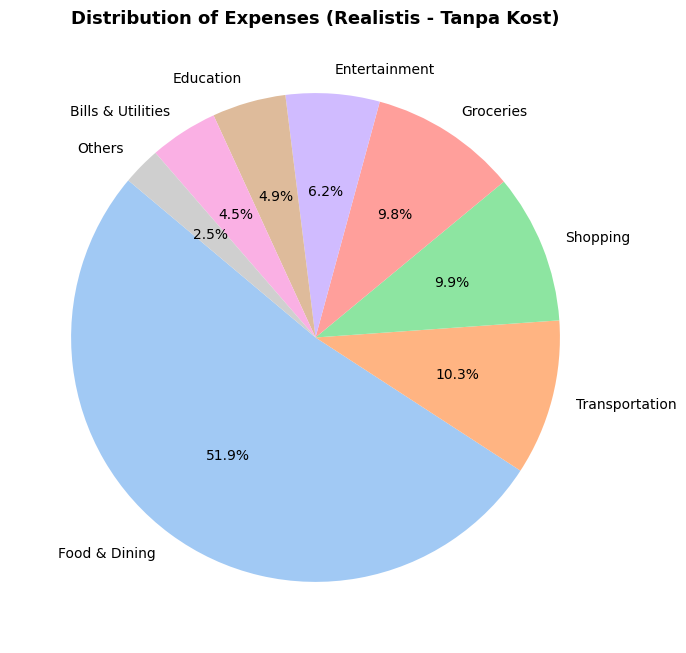

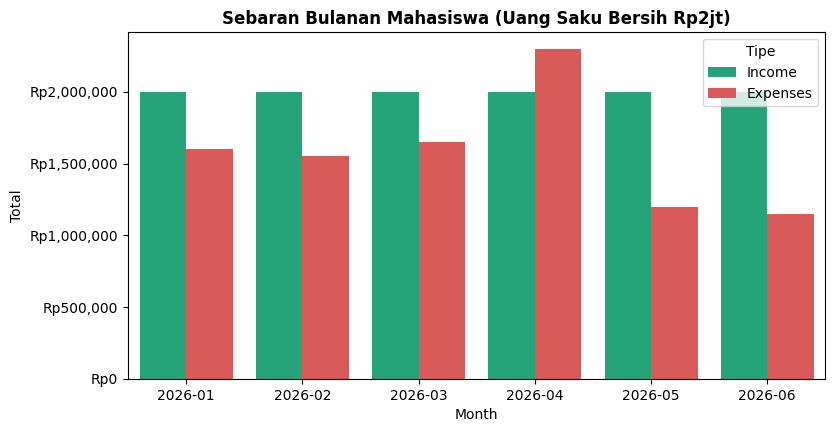

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_new = pd.read_csv('dataset_mahasiswa_realistis.csv')
df_expense = df_new[df_new['TransactionType'] == 'Expenses']

# 1. PIE CHART DISTRIBUSI BARU
plt.figure(figsize=(7, 7))
cat_data = df_expense.groupby('TransactionCategory')['Amount'].sum().sort_values(ascending=False)
cat_data.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribution of Expenses (Realistis - Tanpa Kost)', fontsize=13, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

# 2. SEBARAN BAR CHART MONTHLY (Memastikan total pengeluaran bulanan tetap aman sesuai grafik sebelumnya)
plt.figure(figsize=(9, 4.5))
monthly_sum = df_new.groupby(['Month', 'TransactionType'])['Amount'].sum().unstack(fill_value=0).reset_index()
df_plot = pd.melt(monthly_sum, id_vars=['Month'], value_vars=['Income', 'Expenses'], var_name='Tipe', value_name='Total')
ax = sns.barplot(x='Month', y='Total', hue='Tipe', data=df_plot, palette=['#10B981', '#EF4444'])
plt.title('Sebaran Bulanan Mahasiswa (Uang Saku Bersih Rp2jt)', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "Rp{:,}".format(int(x))))
plt.show()

In [5]:
import pandas as pd

# 1. Load dataset mahasiswa realistis yang baru dibuat
df_transaksi = pd.read_csv('dataset_mahasiswa_realistis.csv')

# 2. Kelompokkan total pengeluaran per bulan berdasarkan kategorinya
# Ini akan mengubah data harian menjadi tabel bulanan dengan kolom-kolom kategori
df_bulanan = df_transaksi.groupby(['Month', 'TransactionCategory'])['Amount'].sum().unstack(fill_value=0).reset_index()

# 3. KORELASI JEMBATAN (Mencocokkan Kategori Aplikasi dengan Variabel Rumus Kamu)
# Kita buat kolom baru sesuai dengan variabel yang dibutuhkan oleh kode kamu:

# --- Kelompok INCOME ---
df_bulanan['Gaji'] = df_transaksi[df_transaksi['TransactionCategory'] == 'Allowance / Salary'].groupby('Month')['Amount'].sum().values
df_bulanan['Investasi'] = 0          # Set 0 dulu karena mahasiswa belum ada investasi aktif
df_bulanan['Pemasukan Lainnya'] = 0  # Set 0

# --- Kelompok NEEDS ---
df_bulanan['Bahan Pokok'] = df_bulanan['Food & Dining']  # Warteg, bubur ayam, kantin masuk makanan pokok
df_bulanan['Protein & Gizi Tambahan'] = 0
df_bulanan['Tempat Tinggal'] = 0                          # 0 karena tinggal sama ortu (bebas kos)
df_bulanan['Sandang'] = 0
df_bulanan['Pajak'] = 0
df_bulanan['Asuransi'] = 0

# Tambahan Kebutuhan Wajib Mahasiswa (Kita masukkan ke Kebutuhan Utama/Bahan Pokok)
# Gabungkan biaya bensin/transport, paket data, dan fotokopi kuliah ke dalam 'Bahan Pokok' / Needs
df_bulanan['Bahan Pokok'] = (
    df_bulanan['Bahan Pokok'] +
    df_bulanan.get('Transportation', 0) +
    df_bulanan.get('Bills & Utilities', 0) +
    df_bulanan.get('Education', 0) +
    df_bulanan.get('Groceries', 0)
)

# --- Kelompok WANTS ---
df_bulanan['Konsumsi Praktis'] = df_bulanan.get('Shopping', 0)  # Checkout Shopee/Tokopedia
df_bulanan['Barang & Jasa Sekunder'] = 0
df_bulanan['Pengeluaran Tidak Esensial'] = df_bulanan.get('Entertainment', 0) # Bioskop, game, netflix
df_bulanan['Sosial & Budaya'] = df_bulanan.get('Others', 0)                   # Jajan cilok, kado wisuda, parkir

# --- Kelompok SAVINGS ---
# Tabungan dihitung dari sisa uang bulanan (Gaji - Total Pengeluaran Nyata)
total_pengeluaran_nyata = df_transaksi[df_transaksi['TransactionType'] == 'Expenses'].groupby('Month')['Amount'].sum().values
df_bulanan['Tabungan / Investasi'] = df_bulanan['Gaji'] - total_pengeluaran_nyata


# =========================================================================
# SEKARANG KODE KAMU SUDAH BISA BERJALAN 100% SECARA OTOMATIS:
# =========================================================================

# Kolom baru hasil kalkulasi dari kode kamu:
df_bulanan['Income'] = (
    df_bulanan['Gaji'] +
    df_bulanan['Investasi'] +
    df_bulanan['Pemasukan Lainnya']
)

df_bulanan['Needs'] = (
    df_bulanan['Bahan Pokok'] +
    df_bulanan['Protein & Gizi Tambahan'] +
    df_bulanan['Tempat Tinggal'] +
    df_bulanan['Sandang'] +
    df_bulanan['Pajak'] +
    df_bulanan['Asuransi']
)

df_bulanan['Wants'] = (
    df_bulanan['Konsumsi Praktis'] +
    df_bulanan['Barang & Jasa Sekunder'] +
    df_bulanan['Pengeluaran Tidak Esensial'] +
    df_bulanan['Sosial & Budaya']
)

df_bulanan['Savings'] = (
    df_bulanan['Tabungan / Investasi']
)

# Tampilkan hasil akhir pengelompokan variabel untuk input model ML kamu
print(df_bulanan[['Month', 'Income', 'Needs', 'Wants', 'Savings']])

TransactionCategory    Month   Income    Needs    Wants  Savings
0                    2026-01  2000000  1161829   438171   400000
1                    2026-02  2000000  1080569   469431   450000
2                    2026-03  2000000  1276507   373493   350000
3                    2026-04  2000000  1126616  1173384  -300000
4                    2026-05  2000000  1007230   192770   800000
5                    2026-06  2000000  1079590    70410   850000
